# Hold-time × sample-size feasibility
**Question:** how many wallets actually live in the copyable box — enough TAKER-opened round-trips at a mid-frequency hold — to matter?

**Reconciliations (why avg-hold alone is misleading):**
- Hold is bucketed **per trade** (not averaged): `<15m / 15m–1h / 1–4h / 4–24h / 24–72h / >72h`, so a wallet that mixes 48h swings and 10-min scalps shows its true spread.
- Only **taker-OPENED** round-trips count (entry taker-share > 0.5) — maker legs are not copyable.
- The feasibility number is **`n_copyable` = taker-opened round-trips with hold in 1–24h**, per wallet — not `total trades × avg-hold≈4h`.

Whole-window (train+test), majors, dust floor $100. Source: `out/hold_size_dist.parquet`.

In [1]:
import numpy as np, polars as pl, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
df = pl.read_parquet('../out/hold_size_dist.parquet')
print('wallets:', df.height)
BANDS = ['lt15m','15m_1h','1_4h','4_24h','24_72h','gt72h']
band_tot = {b:int(df['nb_'+b].sum()) for b in BANDS}
print('taker-opened round-trips by hold band:')
for b in BANDS: print(f'   {b:8s}: {band_tot[b]:>10,}')
def box(nmin, tk):
    m = (df['n_copyable']>=nmin) & (df['taker_share']>=tk)
    return int(m.sum())
print('\nwallets in the COPYABLE box (n_copyable = taker-opened 1-24h holds):')
for nmin in [50,100,200]:
    print(f'   n_copyable>={nmin:3d}: all={box(nmin,0.0):5d} | taker_share>=0.7 {box(nmin,0.7):5d} | >=0.9 {box(nmin,0.9):5d}')

wallets: 29334
taker-opened round-trips by hold band:
   lt15m   :  4,630,918
   15m_1h  :  3,878,364
   1_4h    :  4,363,745
   4_24h   :  6,170,512
   24_72h  :  2,957,847
   gt72h   :  3,339,856

wallets in the COPYABLE box (n_copyable = taker-opened 1-24h holds):
   n_copyable>= 50: all=21305 | taker_share>=0.7 18869 | >=0.9 14956
   n_copyable>=100: all=14225 | taker_share>=0.7 12544 | >=0.9  9860
   n_copyable>=200: all= 8167 | taker_share>=0.7  7149 | >=0.9  5482


## The picture

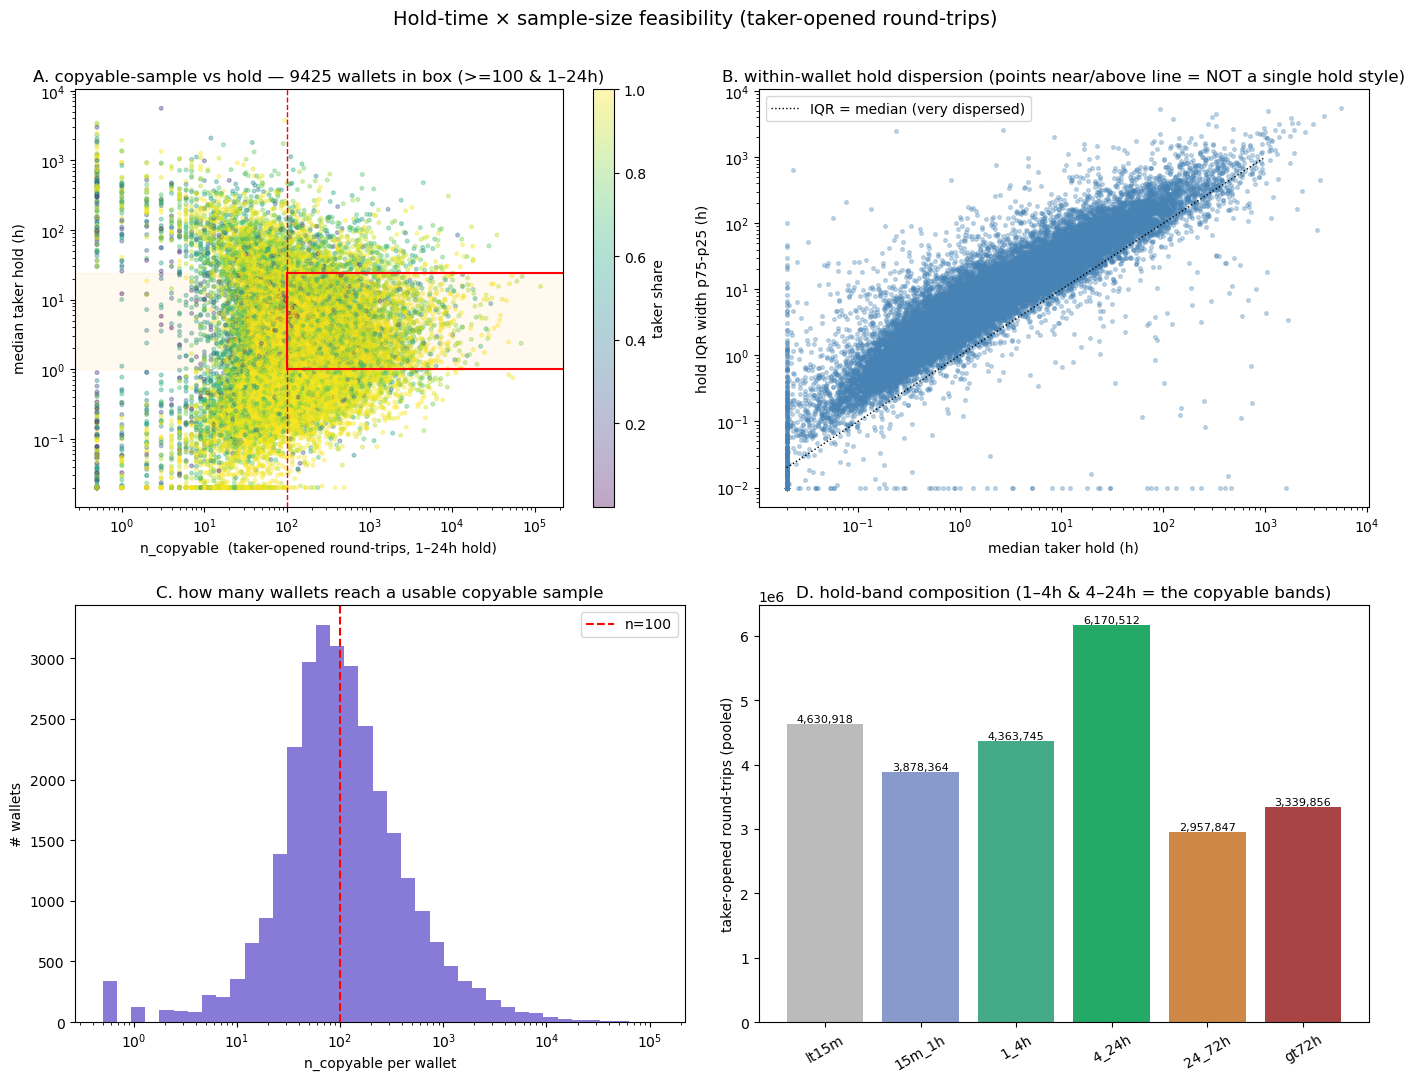

In [2]:
d = df.filter((pl.col('n_tk_close')>=1) & pl.col('med_hold_h').is_finite()).to_pandas()
fig, ax = plt.subplots(2, 2, figsize=(14, 11)); fig.suptitle('Hold-time × sample-size feasibility (taker-opened round-trips)', fontsize=14)
# --- Panel A: n_copyable vs median taker hold, target box highlighted ---
a = ax[0,0]
sc = a.scatter(np.maximum(d['n_copyable'],0.5), np.maximum(d['med_hold_h'],0.02), c=np.clip(d['taker_share'],0,1),
               s=7, alpha=0.35, cmap='viridis')
a.set_xscale('log'); a.set_yscale('log'); a.set_xlabel('n_copyable  (taker-opened round-trips, 1–24h hold)'); a.set_ylabel('median taker hold (h)')
a.axhspan(1,24, color='orange', alpha=0.06); a.axvline(100, color='red', ls='--', lw=1)
a.add_patch(Rectangle((100,1), 1e6, 23, fill=False, edgecolor='red', lw=1.5))
nbox = int(((d['n_copyable']>=100)&(d['med_hold_h']>=1)&(d['med_hold_h']<=24)).sum())
a.set_title(f'A. copyable-sample vs hold — {nbox} wallets in box (>=100 & 1–24h)'); plt.colorbar(sc, ax=a, label='taker share')
# --- Panel B: within-wallet hold DISPERSION (median vs IQR width) — reconciles 'avg is misleading' ---
b = ax[0,1]
iqr = (d['p75_hold_h']-d['p25_hold_h']).clip(lower=0.01)
b.scatter(np.maximum(d['med_hold_h'],0.02), iqr, s=7, alpha=0.3, color='steelblue')
b.set_xscale('log'); b.set_yscale('log'); b.set_xlabel('median taker hold (h)'); b.set_ylabel('hold IQR width p75-p25 (h)')
b.plot([0.02,1000],[0.02,1000],'k:',lw=1,label='IQR = median (very dispersed)'); b.legend()
b.set_title('B. within-wallet hold dispersion (points near/above line = NOT a single hold style)')
# --- Panel C: distribution of copyable sample size ---
c = ax[1,0]
vals = np.clip(d['n_copyable'],0.5,None)
c.hist(vals, bins=np.logspace(np.log10(0.5), np.log10(max(vals.max(),10)), 40), color='slateblue', alpha=0.8)
c.set_xscale('log'); c.axvline(100, color='red', ls='--', label='n=100'); c.legend()
c.set_xlabel('n_copyable per wallet'); c.set_ylabel('# wallets'); c.set_title('C. how many wallets reach a usable copyable sample')
# --- Panel D: where the mass of trades actually is (pooled band totals) ---
e = ax[1,1]
tot = [int(df['nb_'+bb].sum()) for bb in BANDS]
cols = ['#bbb','#89c','#4a8','#2a6','#c84','#a44']
e.bar(range(len(BANDS)), tot, color=cols); e.set_xticks(range(len(BANDS))); e.set_xticklabels(BANDS, rotation=30)
e.set_ylabel('taker-opened round-trips (pooled)'); e.set_title('D. hold-band composition (1–4h & 4–24h = the copyable bands)')
for i,v in enumerate(tot): e.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(rect=[0,0,1,0.97]); import os; os.makedirs('../out/figs_hold', exist_ok=True)
plt.savefig('../out/figs_hold/hold_feasibility.png', dpi=110, bbox_inches='tight'); plt.show()

## Reading it
- **Panel A** is the direct answer to your question: the red box is *≥100 copyable samples AND a 1–24h median hold*. Its count is how many wallets are even eligible for a per-wallet mid-freq test.
- **Panel B** is the reconciliation you asked for: points on/above the dotted line are wallets whose hold *IQR is as wide as their median* — i.e. they do NOT have a single hold style (48h swings + scalps mixed). For those, 'average hold' is meaningless and they can't be cleanly labelled a '4h trader'.
- **Panel C**: the histogram of `n_copyable` with the n=100 line — most wallets fall short.
- **Panel D**: where trades actually concentrate across hold bands.